# E7 - EfficientNet-B3, augmentation only, 224px

| | |
|---|---|
| Architecture | `efficientnet_b3` |
| Imbalance strategy | `augmentation` |
| Input resolution | 224x224 |
| Group | EfficientNet-B3 ablation |
| Optimiser | Adam, lr 1e-3, betas (0.9, 0.999) |
| Batch size | 32 |
| Schedule | max 50 epochs, early stopping on val loss, patience 10 |
| Seed | 42 |

First EfficientNet-B3 run, and the start of the ablation the professor
asked for.

Input is 224px here, deliberately matching MobileNetV2 and ResNet-50 rather than B3's
native 300. That is the only way a difference against E1/E2 can be attributed to the
architecture instead of to a larger input. E10 runs the same configuration at 300 so
the resolution question gets its own answer.

B3 ships with dropout p=0.3, higher than MobileNetV2's 0.2 and unlike ResNet-50 which
has none. Left as-is, consistent with how the other two are handled.

Training is checkpointed after every epoch. If the pod drops, re-run the training cell
and it picks up from the last completed epoch rather than starting over.

In [1]:
import json, sys, time
from pathlib import Path

# Works whether the kernel starts in notebooks/ or at the repo root.
ROOT = Path.cwd()
while not (ROOT / "src" / "ham10000").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

# /workspace is a MooseFS network volume and per-file reads over FUSE were the
# bottleneck, not the GPU: 45 img/s there against 241 img/s from RAM. Notebook 01
# stages a copy into /dev/shm. Fall back to the on-disk copy if it is missing,
# since tmpfs does not survive a pod restart.
FAST = Path("/dev/shm/ham_data")
DATA = FAST if (FAST / "HAM10000_metadata.csv").exists() else ROOT / "data"
RUNS = ROOT / "runs"
print("repo:   ", ROOT)
print("data:   ", DATA, "(RAM)" if str(DATA).startswith("/dev/shm") else "(disk, slower)")

repo:    /workspace/ham10000-cnn-comparison
data:    /dev/shm/ham_data (RAM)


In [2]:
from ham10000.constants import EXPERIMENTS, experiment_label
from ham10000.train import TrainConfig, train_experiment

EXP = "E7"
print(experiment_label(EXP))
print(EXPERIMENTS[EXP])

E7 EfficientNet-B3 @224 / Augmentation only
{'architecture': 'efficientnet_b3', 'strategy': 'augmentation', 'image_size': 224}


## Preflight

Confirms the GPU, the data and the shared split before anything expensive starts.

In [3]:
import torch
from ham10000.split import load_or_create_split, split_hash

assert torch.cuda.is_available(), "No GPU. Stop here."
print("gpu :", torch.cuda.get_device_name(0))

assert (DATA / "HAM10000_metadata.csv").exists(), "Run notebook 01 first."
df, lesion_splits = load_or_create_split(DATA / "HAM10000_metadata.csv",
                                         RUNS / "splits" / "seed42_lesion_stratified.json")
print("split hash :", split_hash(lesion_splits))
print(df.split.value_counts().to_dict())

gpu : NVIDIA RTX A4500
split hash : f35ac1de18678182
{'train': 8012, 'test': 1024, 'val': 979}


## Train

Expect this to take a while. Roughly 30 to 60 minutes on an A40, depending on how early the run stops.

The cell is safe to re-run: if `test_metrics.json` already exists it returns the cached
result instead of retraining. Pass `force_rerun=True` if you genuinely want it redone.

In [9]:
config = TrainConfig(
    experiment_id=EXP,
    data_root=str(DATA),
    output_dir=str(RUNS / EXP),
    seed=42,
    batch_size=32,
    lr=1e-3,
    max_epochs=50,
    patience=10,
    num_workers=16,
)

start = time.time()
result = train_experiment(config)
print(f"\nwall clock: {(time.time() - start) / 60:.1f} min")

E7 is already finished (/workspace/ham10000-cnn-comparison/runs/E7/test_metrics.json).
Set force_rerun=True if you want to train it again from scratch.

wall clock: 0.0 min


## Results

In [11]:
import pandas as pd
from ham10000.constants import CLASS_NAMES

m = result["test_metrics"]
report = m["classification_report"]

print(f"accuracy          {m['accuracy']:.4f}")
print(f"balanced accuracy {m['balanced_accuracy']:.4f}")
print(f"macro F1          {m['macro_f1']:.4f}")
print(f"macro AUC (OvR)   {m['macro_auc_ovr']:.4f}\n")

table = pd.DataFrame([{
    "class": c,
    "precision": report[str(i)]["precision"],
    "recall": report[str(i)]["recall"],
    "f1": report[str(i)]["f1-score"],
    "support": int(report[str(i)]["support"]),
} for i, c in enumerate(CLASS_NAMES)]).set_index("class").round(4)
print(table)

rq2 = (report[str(CLASS_NAMES.index("mel"))]["recall"]
       + report[str(CLASS_NAMES.index("bcc"))]["recall"]) / 2
print(f"\nRQ2 criterion, mean(recall MEL, recall BCC) = {rq2:.4f}")

accuracy          0.8047
balanced accuracy 0.6373
macro F1          0.6742
macro AUC (OvR)   0.9554

       precision  recall      f1  support
class                                    
akiec     0.5952  0.7576  0.6667       33
bcc       0.7500  0.6792  0.7129       53
bkl       0.6250  0.5238  0.5699      105
df        1.0000  0.4615  0.6316       13
mel       0.4859  0.6000  0.5370      115
nv        0.9058  0.9058  0.9058      690
vasc      1.0000  0.5333  0.6957       15

RQ2 criterion, mean(recall MEL, recall BCC) = 0.6396


### Training curve

Val loss is what early stopping watches. Val macro F1 is what actually matters, and the
two do not always move together.

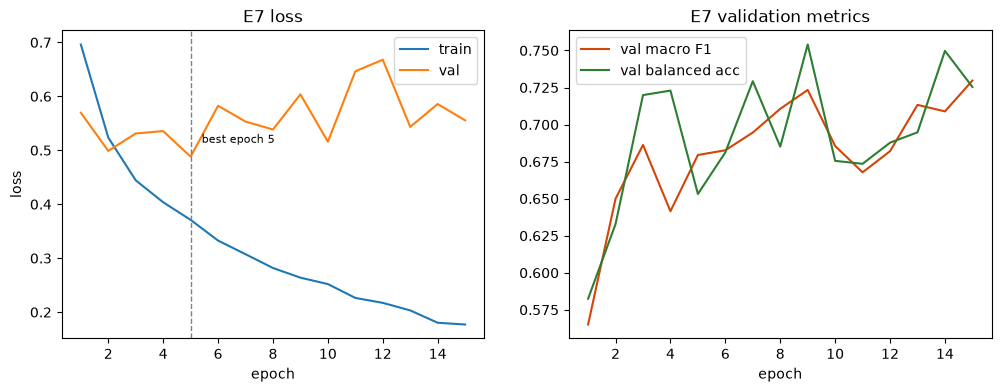

stopped after 15 epochs, best val loss 0.4881 at epoch 5


In [13]:
import matplotlib.pyplot as plt

h = pd.read_csv(RUNS / EXP / "history.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h.epoch, h.train_loss, label="train")
axes[0].plot(h.epoch, h.val_loss, label="val")
best = h.loc[h.val_loss.idxmin()]
axes[0].axvline(best.epoch, ls="--", c="grey", lw=1)
axes[0].annotate(f"best epoch {int(best.epoch)}", (best.epoch, best.val_loss),
                 textcoords="offset points", xytext=(8, 10), fontsize=8)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()
axes[0].set_title(f"{EXP} loss")

axes[1].plot(h.epoch, h.val_macro_f1, color="#D54407", label="val macro F1")
axes[1].plot(h.epoch, h.val_balanced_accuracy, color="#2E7D32", label="val balanced acc")
axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].set_title(f"{EXP} validation metrics")
plt.show()

print(f"stopped after {len(h)} epochs, best val loss {h.val_loss.min():.4f} at epoch {int(best.epoch)}")

### Confusion matrix

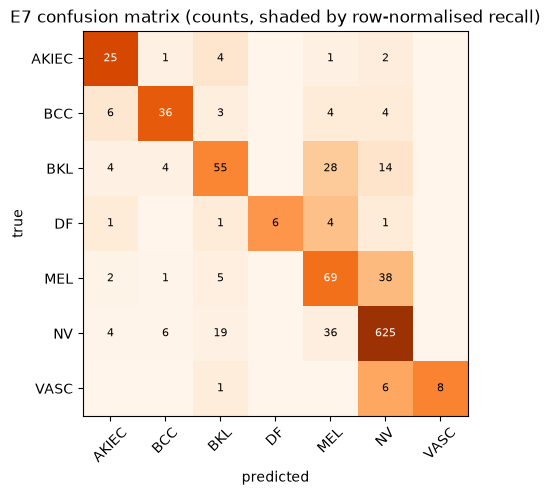

melanomas called NV: 38 of 115
This is the clinically costly error: a cancer sent home as a benign mole.


In [15]:
import numpy as np

cm = np.array(m["confusion_matrix"], dtype=float)
norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(norm, cmap="Oranges", vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        if cm[i, j]:
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=8,
                    color="white" if norm[i, j] > 0.55 else "black")
ax.set_xticks(range(7), [c.upper() for c in CLASS_NAMES], rotation=45)
ax.set_yticks(range(7), [c.upper() for c in CLASS_NAMES])
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"{EXP} confusion matrix (counts, shaded by row-normalised recall)")
ax.grid(False)
plt.show()

mel, nv = CLASS_NAMES.index("mel"), CLASS_NAMES.index("nv")
print(f"melanomas called NV: {int(cm[mel, nv])} of {int(cm[mel].sum())}")
print("This is the clinically costly error: a cancer sent home as a benign mole.")

### Files written

These five are what the analysis notebooks read. Nothing later re-derives them.

In [17]:
for f in sorted((RUNS / EXP).iterdir()):
    print(f"{f.name:<24} {f.stat().st_size/1e6:>8.2f} MB")

checkpoint_best.pt         129.34 MB
checkpoint_last.pt         129.34 MB
config.json                  0.00 MB
history.csv                  0.00 MB
test_metrics.json            0.00 MB
test_predictions.csv         0.02 MB
